# The Metal Corpus
### A Linguistic Analysis of Heavy Metal Lyrics

*A data science portfolio project by William Anderson*

---

## Setup

In [89]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('/Users/williamanderson/VisualStudio/metal_lyrics91.db')

subgenres = ['traditional', 'thrash', 'death', 'black', 'groove', 'progressive', 'doom', 'power', 'glam', 'nu', 'other']

df_words = pd.read_sql("SELECT * FROM words", conn)
df_artists = pd.read_sql("SELECT * FROM artists", conn)
df_releases = pd.read_sql("SELECT * FROM releases", conn)
df_songs = pd.read_sql("SELECT * FROM songs", conn)

print(f"Unique words: {len(df_words):,}")
print(f"Artists: {len(df_artists):,}")
print(f"Releases: {len(df_releases):,}")
print(f"Songs: {len(df_songs):,}")

Unique words: 114,040
Artists: 1,005
Releases: 6,330
Songs: 47,981


---

## Dataset Overview

### Word Count by Subgenre

Note: raw word counts reflect both the verbosity of a genre *and* how many bands are represented in the dataset. Traditional and thrash metal have the most data simply because more bands exist in those categories. The analyses that follow normalize for this where appropriate.

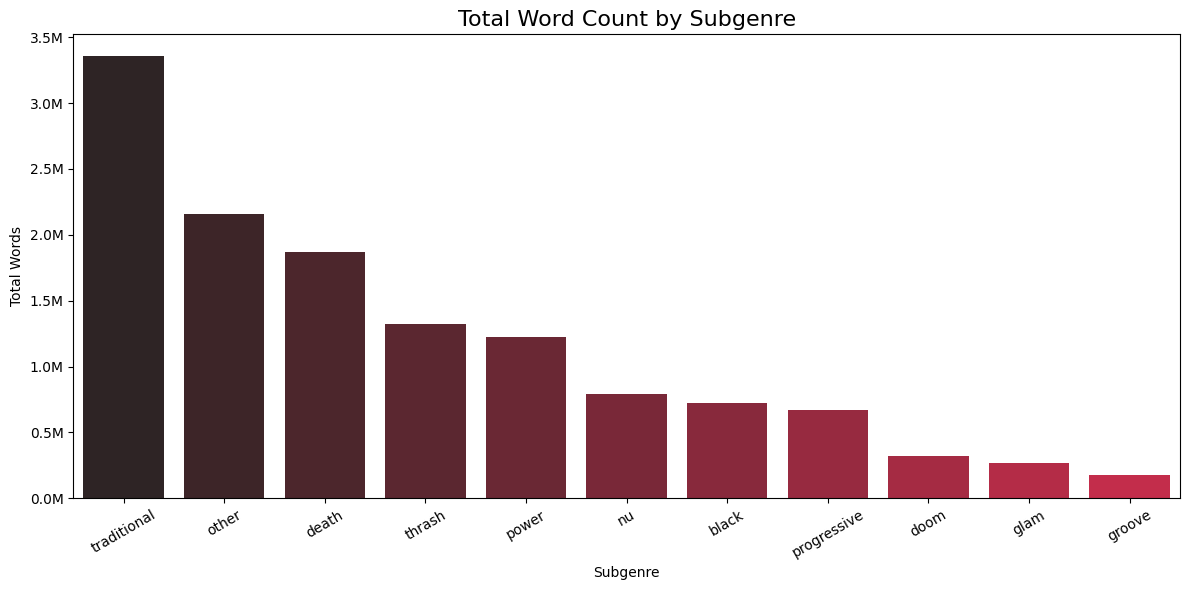

   subgenre  total_words
traditional      3353541
      other      2156792
      death      1866086
     thrash      1326061
      power      1225501
         nu       791721
      black       725991
progressive       670859
       doom       317672
       glam       264953
     groove       179099


In [90]:
# Word count by subgenre

df_words = pd.read_sql("SELECT * FROM words", conn)

totals = {s: df_words[s].sum() for s in subgenres}
totals_df = pd.DataFrame(list(totals.items()), columns=['subgenre', 'total_words'])
totals_df = totals_df.sort_values('total_words', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=totals_df, x='subgenre', y='total_words', hue='subgenre', palette='dark:crimson', legend=False)
plt.title('Total Word Count by Subgenre', fontsize=16)
plt.xlabel('Subgenre')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
plt.ylabel('Total Words')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(totals_df.to_string(index=False))

---

###  Country Representation

This dataset includes lyrics of bands from 45 countries. The United States leads by a significant margin, showing both the country's outsized influence on metal's development and the sheer size of its music scene. The next highest-represented countries are the UK, Sweden, and Germany, three countries whose influence on heavy metal is disproportionate to their size. This sets up an interesting per-capita question explored later in the findings.

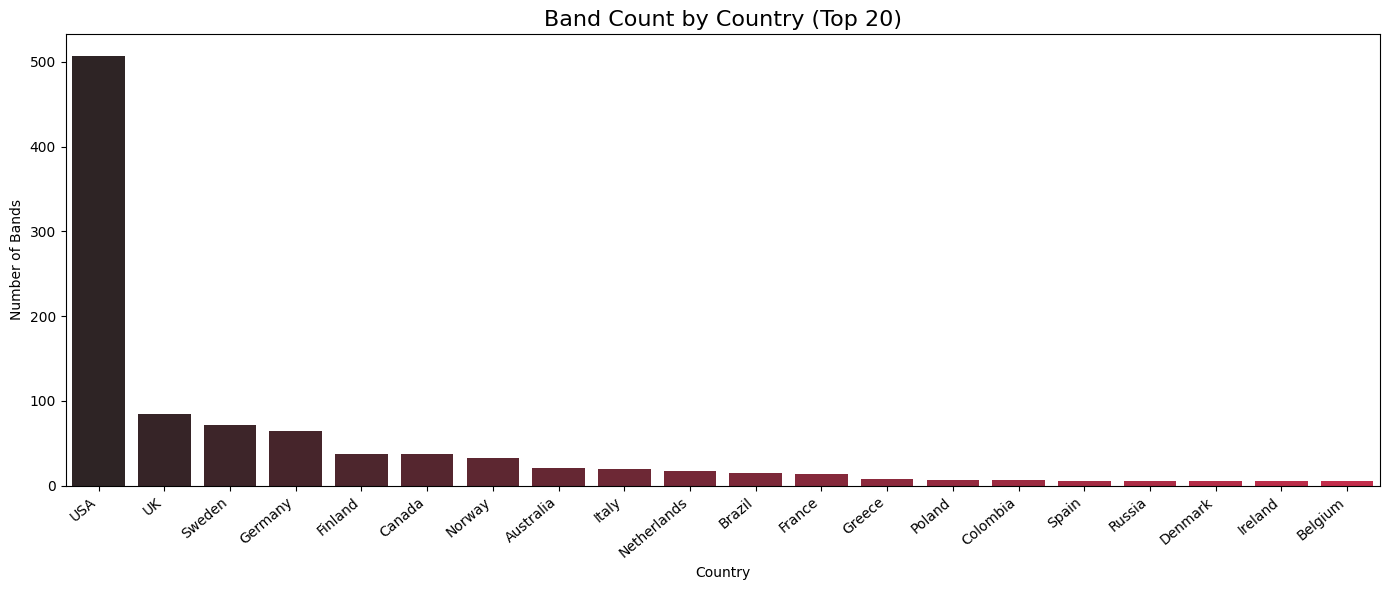

    country  band_count
        USA         507
         UK          85
     Sweden          72
    Germany          65
    Finland          37
     Canada          37
     Norway          32
  Australia          21
      Italy          20
Netherlands          17
     Brazil          15
     France          14
     Greece           8
     Poland           7
   Colombia           7
      Spain           6
     Russia           6
    Denmark           6
    Ireland           5
    Belgium           5


In [91]:
df_artists = pd.read_sql("SELECT country, COUNT(*) as band_count FROM artists GROUP BY country ORDER BY band_count DESC LIMIT 20", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_artists, x='country', y='band_count', hue='country', palette='dark:crimson', legend=False)
plt.title('Band Count by Country (Top 20)', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Number of Bands')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print(df_artists.to_string(index=False))

---

### Release Year Distribution

The corpus spans from 1968 to 2026. The earliest release included is the song *Helter Skelter* by The Beatles, and the first true "metal" album is Black Sabbath's self-titled album from 1970. Release count grows steadily through the 70s, 80s, and 90s before peaking in 2004, with 216. The decline starting in the mid-2010's is somewhat misleading; it likely reflects a selection bias towards the releases catalogued online and used in this project, not a decline in metal output. The album *Painkiller* (1990) by Judas Priest has had 36 years to earn its reputation; a 2022 release hasn't had that time yet.

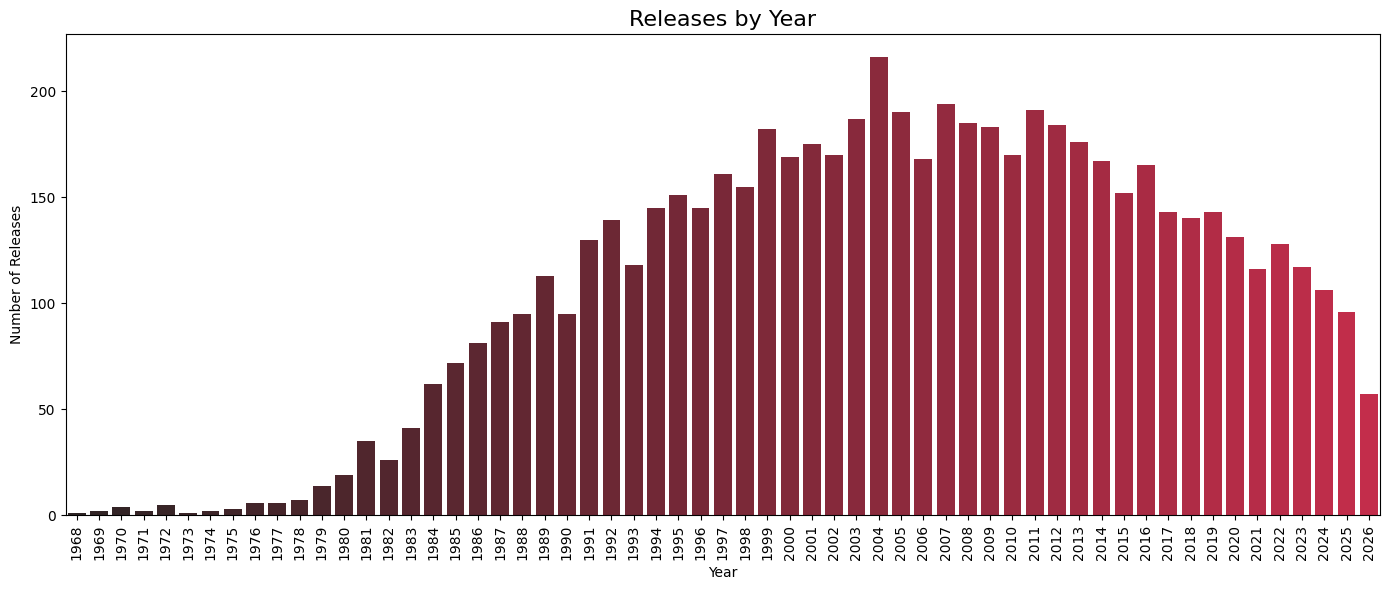

Earliest release: 1968
Most recent release: 2026
Most active year: 2004 (216 releases)


In [98]:
df_years = pd.read_sql("""
    SELECT year, COUNT(*) as release_count
    FROM releases
    WHERE year != 'Unknown'
    GROUP BY year
    ORDER BY year
""", conn)

df_years['year'] = pd.to_numeric(df_years['year'], errors='coerce')
df_years = df_years.dropna()

plt.figure(figsize=(14, 6))
sns.barplot(data=df_years, x='year', y='release_count', hue='year', palette='dark:crimson', legend=False)
plt.title('Releases by Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Earliest release: {int(df_years['year'].min())}")
print(f"Most recent release: {int(df_years['year'].max())}")
print(f"Most active year: {int(df_years.loc[df_years['release_count'].idxmax(), 'year'])} ({df_years['release_count'].max()} releases)")

---

### Vocalist Gender Breakdown

95% of the releases in this dataset feature male vocalists; releases with female vocalists make up almost 5%, and bands with both male and female vocalists make up a fraction of a percent. Metal has always been a male-dominated music genre, and I made a deliberate effort to seek out bands with female vocalists to improve representation in this dataset. 

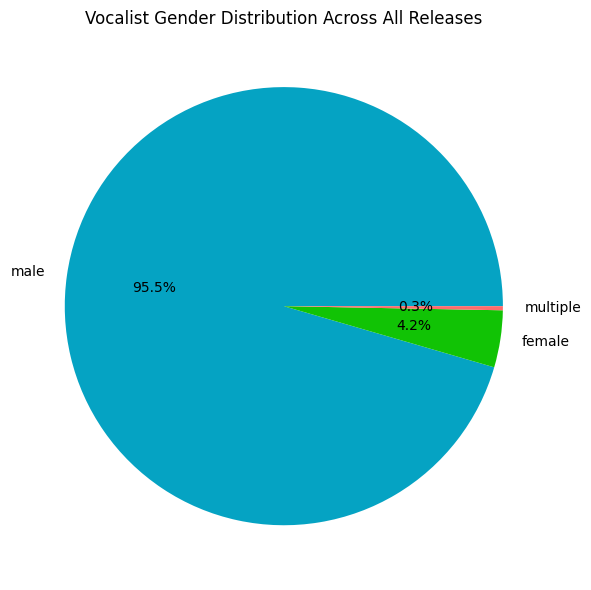

vocalist_gender  count
           male   6045
         female    266
       multiple     19


In [94]:
df_gender = pd.read_sql("""
    SELECT vocalist_gender, COUNT(*) as count
    FROM releases
    GROUP BY vocalist_gender
    ORDER BY count DESC
""", conn)

plt.figure(figsize=(8, 6))
plt.pie(df_gender['count'], labels=df_gender['vocalist_gender'], autopct='%1.1f%%', 
        colors=['#05a3c3', '#11c305', '#FF6B6B', '#FFB3B3'])
plt.title('Vocalist Gender Distribution Across All Releases', fontsize=12)
plt.tight_layout()
plt.show()

print(df_gender.to_string(index=False))

---

### Vocalist Gender by Subgenre

Of the eight subgenres with the highest female vocalist representation, only one maps directly to one of the ten named subgenres in this analysis: Nu Metal. Symphonic Metal (44.7%) and Gothic Metal (39.3%) both significantly outperform Nu Metal's representation, but were collapsed into the broader categories of Power Metal and Other, respectively. 

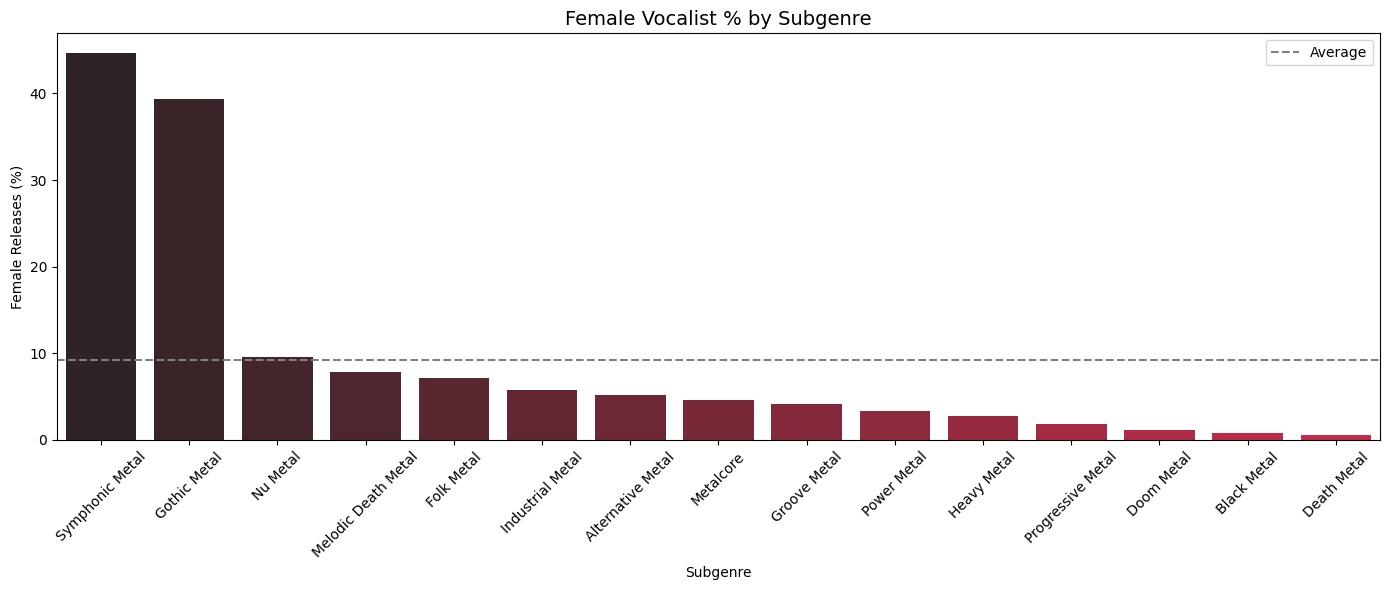

      subgenre_name  female_releases  male_releases  total_releases  female_pct
    Symphonic Metal              101            125             226        44.7
       Gothic Metal               44             68             112        39.3
           Nu Metal               29            273             302         9.6
Melodic Death Metal               13            150             164         7.9
         Folk Metal                8            103             112         7.1
   Industrial Metal                4             65              69         5.8
  Alternative Metal               10            180             191         5.2
          Metalcore               15            312             327         4.6
       Groove Metal                3             68              71         4.2
        Power Metal               13            384             397         3.3
        Heavy Metal               52           1789            1844         2.8
  Progressive Metal                7    

In [122]:
df_gender_subgenre = pd.read_sql("""
    SELECT 
        subgenre_name,
        SUM(CASE WHEN vocalist_gender = 'female' THEN 1 ELSE 0 END) as female_releases,
        SUM(CASE WHEN vocalist_gender = 'male' THEN 1 ELSE 0 END) as male_releases,
        COUNT(*) as total_releases,
        ROUND(100.0 * SUM(CASE WHEN vocalist_gender = 'female' THEN 1 ELSE 0 END) / COUNT(*), 1) as female_pct
    FROM release_subgenres
    GROUP BY subgenre_name
    HAVING total_releases > 10
    AND subgenre_name LIKE '%Metal%'
    AND female_releases > 0
    ORDER BY female_pct DESC
    LIMIT 100
""", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_gender_subgenre, x='subgenre_name', y='female_pct',
            hue='subgenre_name', palette='dark:crimson', legend=False)
plt.title('Female Vocalist % by Subgenre', fontsize=14)
plt.xlabel('Subgenre')
plt.ylabel('Female Releases (%)')
plt.tick_params(axis='x', rotation=45)
plt.axhline(y=df_gender_subgenre['female_pct'].mean(), color='gray', linestyle='--', label='Average')
plt.legend()
plt.tight_layout()
plt.show()

print(df_gender_subgenre[['subgenre_name', 'female_releases', 'male_releases', 'total_releases', 'female_pct']].to_string(index=False))